In [24]:
# ==========================================================
# Advanced Weather Analysis
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [25]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/raw/weather.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data/raw/Global Weather Repository.csv"

df = pd.read_csv(DATA_PATH)

df["last_updated"] = pd.to_datetime(df["last_updated"])

print(df.shape)

df.head()

(151047, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [26]:
# ==========================================================
# Average Temperature by Country
# ==========================================================

country_temp = (
    df.groupby("country")["temperature_celsius"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

country_temp.head(10)

,country,temperature_celsius
0,Saudi Arabien,45.000000
1,Marrocos,40.300000
2,Turkménistan,37.800000
3,Турция,34.000000
4,Qatar,32.455168
5,United Arab Emirates,32.287629
6,Cambodia,32.054452
7,Oman,31.816108
8,Djibouti,31.382794
9,Bangladesh,31.261290


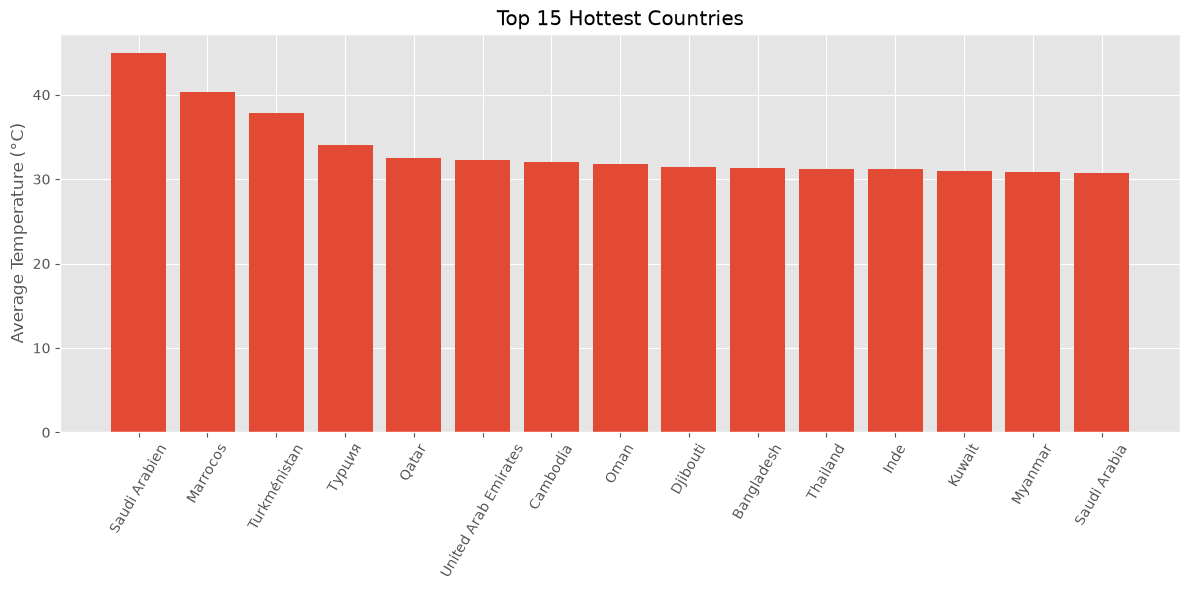

In [27]:
# ==========================================================
# Top Hottest Countries
# ==========================================================

top15 = country_temp.head(15)

plt.figure(figsize=(12,6))

plt.bar(
    top15["country"],
    top15["temperature_celsius"]
)

plt.xticks(rotation=60)

plt.ylabel("Average Temperature (°C)")
plt.title("Top 15 Hottest Countries")

plt.tight_layout()

plt.show()

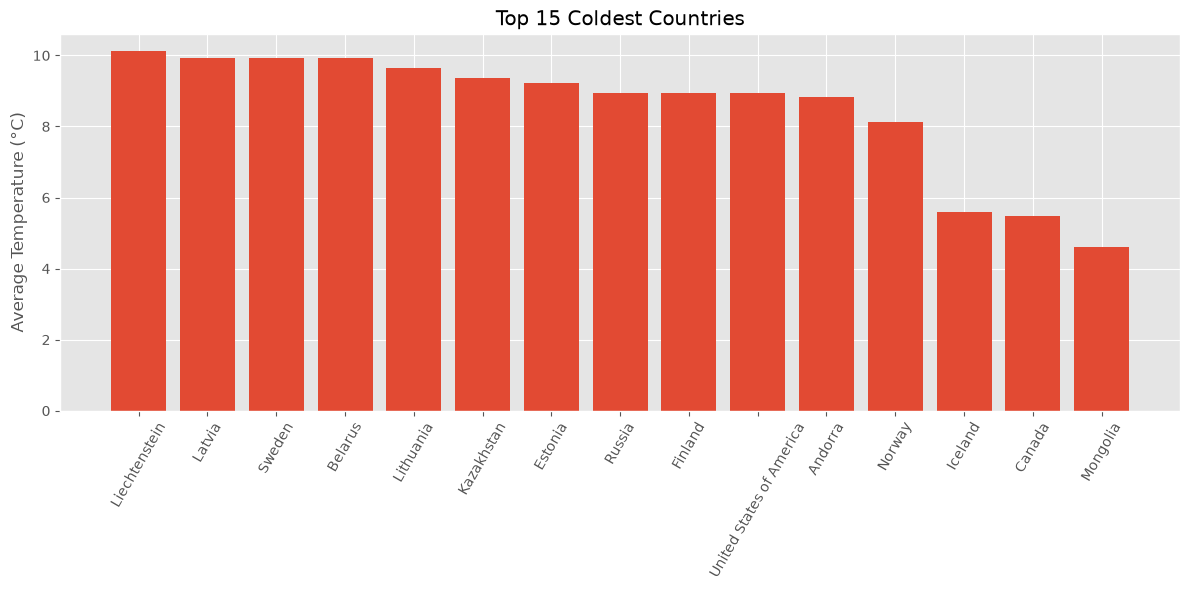

In [28]:
# ==========================================================
# Top Coldest Countries
# ==========================================================

cold15 = country_temp.tail(15)

plt.figure(figsize=(12,6))

plt.bar(
    cold15["country"],
    cold15["temperature_celsius"]
)

plt.xticks(rotation=60)

plt.ylabel("Average Temperature (°C)")
plt.title("Top 15 Coldest Countries")

plt.tight_layout()

plt.show()

In [29]:
# ==========================================================
# Air Quality Correlation
# ==========================================================

air_cols = [

    "temperature_celsius",

    "humidity",

    "air_quality_PM2.5",

    "air_quality_PM10",

    "air_quality_Ozone",

    "air_quality_Carbon_Monoxide"

]

corr = df[air_cols].corr()

corr

,temperature_celsius,humidity,air_quality_PM2.5,air_quality_PM10,air_quality_Ozone,air_quality_Carbon_Monoxide
temperature_celsius,1.000000,-0.340310,0.063470,0.113155,0.249057,-0.002400
humidity,-0.340310,1.000000,-0.220443,-0.242651,-0.403920,-0.075928
air_quality_PM2.5,0.063470,-0.220443,1.000000,0.652485,0.044986,0.610763
air_quality_PM10,0.113155,-0.242651,0.652485,1.000000,0.090002,0.163120
air_quality_Ozone,0.249057,-0.403920,0.044986,0.090002,1.000000,-0.084130
air_quality_Carbon_Monoxide,-0.002400,-0.075928,0.610763,0.163120,-0.084130,1.000000


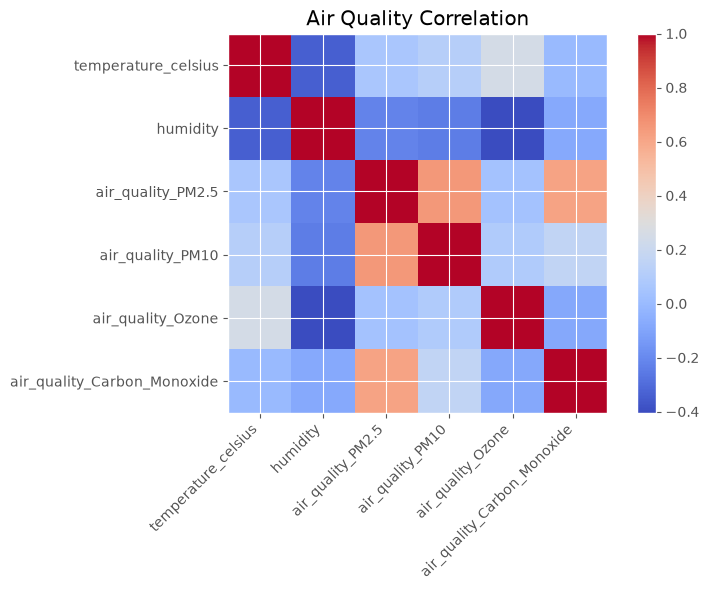

In [30]:
# ==========================================================
# Air Quality Heatmap
# ==========================================================

plt.figure(figsize=(8,6))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Air Quality Correlation")

plt.tight_layout()

plt.show()

In [31]:
# ==========================================================
# Isolation Forest
# ==========================================================

features = [

    "temperature_celsius",

    "humidity",

    "pressure_mb",

    "wind_kph",

    "precip_mm"

]

model = IsolationForest(

    contamination=0.02,

    random_state=42

)

df["anomaly"] = model.fit_predict(
    df[features]
)

df["anomaly"].value_counts()

anomaly
 1    148026
-1      3021
Name: count, dtype: int64

In [32]:
# ==========================================================
# Abnormal Weather Records
# ==========================================================

anomalies = df[
    df["anomaly"] == -1
]

print(f"Total anomalies: {len(anomalies)}")

anomalies.head(20)

Total anomalies: 3021


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,anomaly
176,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,1715849100,2024-05-16 21:45:00,23.0,73.4,Moderate rain,20.6,33.1,80,E,1016.0,29.99,2.09,0.08,100,100,25.2,77.3,6.0,3.0,1.0,35.3,56.8,217.0,36.8,0.1,0.1,2.4,6.3,1,1,07:04 AM,06:10 PM,01:47 PM,12:33 AM,Waxing Gibbous,55,-1
219,Brunei Darussalam,Bandar Seri Begawan,4.88,114.93,Asia/Brunei,1715868000,2024-05-16 22:00:00,27.0,80.6,Patchy light rain with thunder,6.9,11.2,150,SSE,1010.0,29.83,3.01,0.12,100,75,31.3,88.4,7.0,4.0,1.0,11.4,18.4,567.4,51.5,7.4,2.4,9.5,9.8,1,1,06:06 AM,06:27 PM,01:06 PM,12:54 AM,Waxing Gibbous,55,-1
317,Netherlands,Amsterdam,52.37,4.89,Europe/Amsterdam,1715868000,2024-05-16 16:00:00,20.0,68.0,Partly cloudy,12.5,20.2,180,S,1003.0,29.62,2.42,0.10,68,50,20.0,68.0,10.0,6.0,4.0,17.0,27.4,263.7,29.0,32.9,3.2,12.1,13.0,1,2,05:43 AM,09:32 PM,01:39 PM,03:40 AM,Waxing Gibbous,55,-1
371,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,1715868900,2024-05-17 03:15:00,23.0,73.4,Light rain,11.9,19.1,130,SE,1017.0,30.03,2.29,0.09,94,100,25.3,77.5,8.0,4.0,1.0,35.9,57.8,217.0,38.6,0.0,0.1,2.2,6.4,1,1,07:04 AM,06:10 PM,01:47 PM,12:33 AM,Waxing Gibbous,55,-1
490,Luxembourg,Luxembourg,49.61,6.13,Europe/Luxembourg,1715961600,2024-05-17 18:00:00,12.0,53.6,Heavy rain at times,16.1,25.9,280,W,1008.0,29.77,1.70,0.07,94,75,9.2,48.5,4.5,2.0,3.0,27.8,44.7,193.6,76.5,5.6,0.3,0.9,1.0,1,1,05:48 AM,09:17 PM,02:48 PM,03:41 AM,Waxing Gibbous,64,-1
746,Sri Lanka,Colombo,6.93,79.85,Asia/Colombo,1716042600,2024-05-18 20:00:00,25.0,77.0,Light rain,5.6,9.0,150,SSE,1007.0,29.74,3.21,0.13,100,50,27.8,82.0,8.0,4.0,1.0,21.3,34.2,253.7,42.2,5.4,2.5,1.8,3.6,1,1,05:54 AM,06:20 PM,02:24 PM,02:06 AM,Waxing Gibbous,73,-1
852,Iceland,Grindavik,63.83,-22.43,Atlantic/Reykjavik,1716128100,2024-05-19 14:15:00,4.0,39.2,Light rain,28.6,46.1,60,ENE,1007.0,29.74,1.00,0.04,87,100,-2.3,27.9,8.0,4.0,1.0,36.9,59.4,230.3,82.3,0.4,1.7,0.5,0.5,1,1,04:05 AM,10:50 PM,05:26 PM,03:48 AM,Waxing Gibbous,81,-1
880,Maldives,Felidhoo,3.48,73.53,Indian/Maldives,1716128100,2024-05-19 19:15:00,28.8,83.9,Light rain shower,25.1,40.3,274,W,1008.0,29.76,1.02,0.04,80,100,34.2,93.5,10.0,6.0,1.0,36.8,59.3,213.6,32.9,0.0,0.1,1.9,5.3,1,1,05:54 AM,06:11 PM,03:01 PM,02:38 AM,Waxing Gibbous,81,-1
935,Solomon Islands,Honiara,-9.43,159.95,Pacific/Guadalcanal,1716128100,2024-05-20 01:15:00,25.0,77.0,Partly cloudy,2.2,3.6,10,N,1008.0,29.77,13.05,0.51,94,75,28.4,83.0,10.0,6.0,1.0,3.7,6.0,217.0,24.7,0.6,0.3,0.5,0.6,1,1,06:27 AM,06:06 PM,03:02 PM,02:44 AM,Waxing Gibbous,81,-1
946,Syria,Damascus,33.50,36.30,Asia/Damascus,1716128100,2024-05-19 17:15:00,34.0,93.2,Sunny,25.5,41.0,220,SW,1010.0,29.83,0.00,0.00,14,0,32.0,89.6,10.0,6.0,8.0,30.0,48.2,201.9,90.1,2.4,2.6,13.5,37.7,1,2,05:32 AM,07:32 PM,03:46 PM,03:06 AM,Waxing Gibbous,81,-1


In [33]:
# ==========================================================
# SHAP Feature Importance
# ==========================================================

import shap

# Use a smaller sample for SHAP (faster)
sample_df = df.sample(
    n=2000,
    random_state=42
)

features = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

X = sample_df[features]
y = sample_df["temperature_celsius"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

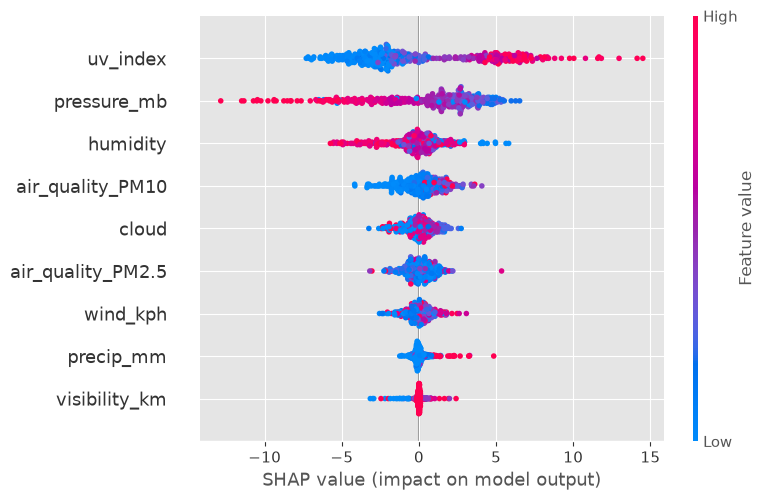

In [34]:
# ==========================================================
# SHAP Summary
# ==========================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

In [35]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature":features,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,uv_index,0.334504
1,pressure_mb,0.238618
0,humidity,0.068386
8,air_quality_PM10,0.067594
4,cloud,0.065673
5,visibility_km,0.061775
7,air_quality_PM2.5,0.057517
3,precip_mm,0.054556
2,wind_kph,0.051376


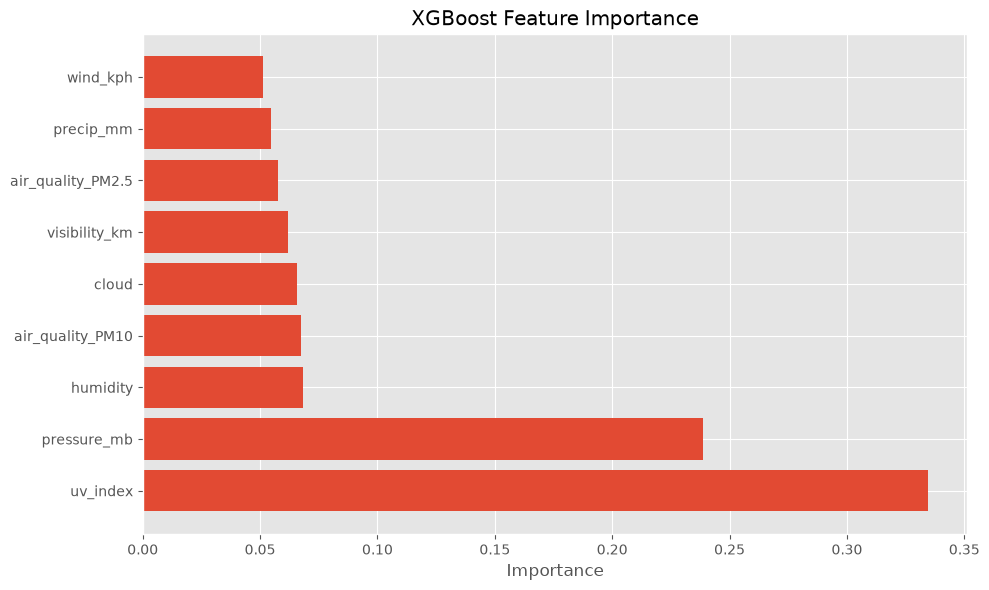

In [36]:
# ==========================================================
# Feature Importance Chart
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [37]:
# ==========================================================
# Save Feature Importance
# ==========================================================

os.makedirs(
    "../outputs/results",
    exist_ok=True
)

importance.to_csv(

    "../outputs/results/feature_importance.csv",

    index=False

)

print("Feature Importance Saved.")

Feature Importance Saved.


In [38]:
# ==========================================================
# Final Insights
# ==========================================================

print("="*60)

print("GLOBAL WEATHER ANALYSIS SUMMARY")

print("="*60)

print()

print(f"Dataset Size : {len(df):,} records")

print(f"Countries : {df['country'].nunique()}")

print(f"Locations : {df['location_name'].nunique()}")

print()

print(f"Highest Temperature : {df['temperature_celsius'].max():.2f} °C")

print(f"Lowest Temperature : {df['temperature_celsius'].min():.2f} °C")

print(f"Average Temperature : {df['temperature_celsius'].mean():.2f} °C")

print()

print("Top 5 Important Features")

print(importance.head())

print()

print("Best Machine Learning Model")

print("XGBoost")

print()

print("="*60)

GLOBAL WEATHER ANALYSIS SUMMARY

Dataset Size : 151,047 records
Countries : 211
Locations : 268

Highest Temperature : 79.30 °C
Lowest Temperature : -29.80 °C
Average Temperature : 21.33 °C

Top 5 Important Features
            Feature  Importance
6          uv_index    0.334504
1       pressure_mb    0.238618
0          humidity    0.068386
8  air_quality_PM10    0.067594
4             cloud    0.065673

Best Machine Learning Model
XGBoost



In [39]:
# ==========================================================
# Save Report
# ==========================================================

report = f"""
WeatherTrendAI Summary

Dataset Size : {len(df)}

Countries : {df['country'].nunique()}

Locations : {df['location_name'].nunique()}

Highest Temperature : {df['temperature_celsius'].max():.2f}

Lowest Temperature : {df['temperature_celsius'].min():.2f}

Average Temperature : {df['temperature_celsius'].mean():.2f}

Best Model : XGBoost

R2 Score : 0.6898
"""

with open(

    "../outputs/reports/summary.txt",

    "w"

) as f:

    f.write(report)

print("Summary Report Saved.")

Summary Report Saved.


In [41]:
# ==========================================================
# Spatial Analysis
# ==========================================================

import folium
from folium.plugins import MarkerCluster

In [42]:
# ==========================================================
# Prepare Map Data
# ==========================================================

map_df = df[
    [
        "country",
        "location_name",
        "latitude",
        "longitude",
        "temperature_celsius",
        "humidity",
        "condition_text"
    ]
].copy()

# Use a sample to keep the map responsive
map_df = map_df.sample(
    n=min(1000, len(map_df)),
    random_state=42
)

map_df.head()

,country,location_name,latitude,longitude,temperature_celsius,humidity,condition_text
100843,Lebanon,Beirut,33.8719,35.5097,25.2,57,Sunny
108746,Andorra,Andorra La Vella,42.5000,1.5167,-8.0,58,Clear
141193,Hungary,Budapest,47.5000,19.0833,12.3,50,Sunny
3299,United Arab Emirates,Abu Dhabi,24.4700,54.3700,39.0,18,Sunny
115648,Iraq,Baghdad,33.3386,44.3939,9.1,37,Partly cloudy


In [43]:
# ==========================================================
# Interactive Weather Map
# ==========================================================

world_map = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron"
)

cluster = MarkerCluster().add_to(world_map)

for _, row in map_df.iterrows():

    popup = f"""
    <b>{row['location_name']}, {row['country']}</b><br>
    🌡 Temperature: {row['temperature_celsius']} °C<br>
    💧 Humidity: {row['humidity']} %<br>
    ☁ Condition: {row['condition_text']}
    """

    if row["temperature_celsius"] >= 35:
        color = "red"
    elif row["temperature_celsius"] >= 20:
        color = "orange"
    elif row["temperature_celsius"] >= 10:
        color = "green"
    else:
        color = "blue"

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup
    ).add_to(cluster)

world_map